# Error Correction Model Parameter Estimation

The Error Correction for two $I(1)$ processes, $X_t$ and $Y_t$ the ECM is given by,

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \left( Y_{t-1} - \beta X_{t-1} \right) + \nu_t
\end{align}
\tag{1}
$

where $\nu_t \sim \text{Normal}(0, \sigma^2)$.</br>

To perform parameter estimation let,

$
\begin{align}
\varepsilon_{t-1} = Y_{t-1} - \beta X_{t-1}
\end{align}
\tag{2}
$

OLS is used to used to estimate $\beta$ to obtain,

$
\begin{align}
\hat{\varepsilon}_{t-1} = Y_{t-1} - \hat{\beta} X_{t-1}
\end{align}
\tag{3}
$

where $\hat{\beta}$ is the OLS estimate of $\beta$. Next the ADF test is used to test $\hat{\varepsilon}_{t-1}$ for stationarity. Replacing the $Y_{t-1} - \beta X_{t-1}$ term in the ECM with $\hat{\varepsilon}_{t-1}$ gives

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \hat{\varepsilon}_{t-1} + \nu_t
\end{align}
\tag{4}
$

Next $\gamma$ and $\lambda$ can be estimated using OLS. This is called the Granger two-step process.

In [85]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
import statsmodels.api as sm

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import ecm, stats, adf, arima
from lib.plots import comparison, ecm_beta
from lib.utils import create_ensemble

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [86]:
def ecm_comparison_plot(xt, yt, φ, β, γ, λ, σ=1.0):
    title = f"ECM Simulation: φ={φ}, β={β}, γ={γ}, λ={λ}, σ={σ}"
    εt = yt - β * xt
    labels = [r"$x_t$", r"$y_t$", r"$\hat{\varepsilon}=y_t - \hat{\beta}x_t$"]
    comparison([xt, yt, εt], title=title, ylabel=r"$S_t$", xlabel=r"$t$", labels=labels, lw=1)

### $\beta$ Estimation

In [87]:
φ = 0.5
λ = -0.5
γ = 0.5
β = 0.5
npts = 1000

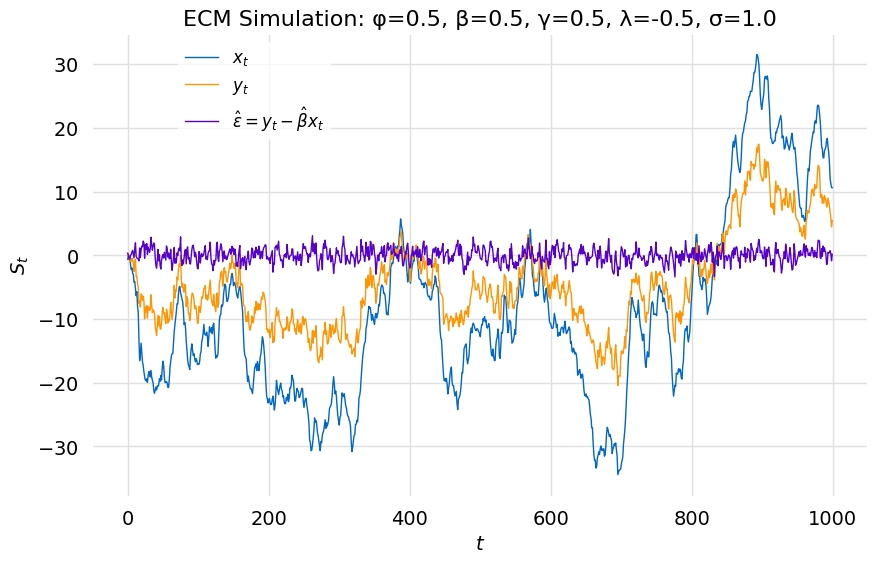

In [88]:
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

#### Residual Stationarity

In [89]:
εt = yt - β * xt
result, result_model = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -18.462       │
├────────────────┼───────────────┤
│ pvalue         │   3.92807e-29 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 999           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [90]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "label": "$t$",
                "value": -18.461966546404053,
                "hyp_test_id": "a0d443d7-163a-4832-9453-34966c6072e8"
            },
            "pval": {
                "label": "$p-value$",
                "value": 3.928067590067079e-29,
                "hyp_test_id": "a0d443d7-163a-4832-9453-34966c6072e8"
            },
            "params": [],
            "sig": {
                "label": "1%",
                "value": 0.01,
                "hyp_test_id": "a0d443d7-163a-4832-9453-34966c6072e8"
            },
            "lower": {
                "label": "$t_L$",
                "value": -2.5679816723029334,
                "hyp_test_id": "a0d443d7-163a-4832-9453-34966c6072e8"
            },
            "upper": null,
            "hyp_test_id": "a0d443d7-163a-4832-9453-34966c6

In [91]:
result, beta_result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                 4.177e+04
Date:                Sun, 01 Oct 2023   Prob (F-statistic):               0.00
Time:                        12:42:27   Log-Likelihood:                -1530.3
No. Observations:                1000   AIC:                             3065.
Df Residuals:                     998   BIC:                             3074.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0390      0.042      0.933      0.351      -0.043       0.121
x1             0.5062      0.002    204.371      0.000       0.501       0.511
==============================================================================
Omnibus:                        1.763   Durbin-Watson:                   1.025
Prob(Omnibus):                  0.414   Jarque-Bera (JB):                1.835
Skew:                          -0.086   Prob(JB):                        0.400
Kurtosis:                       2.881   Cond. No.                         20.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [92]:
print(beta_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.03904014920435883,
      "err": 0.041832868140455,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "746f2c71-7591-4fe2-b080-df37865a78e1",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.5062195139638628,
         "err": 0.0024769586119998055,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "746f2c71-7591-4fe2-b080-df37865a78e1",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9766635255905806,
   "param_transforms": [
      {
         "param": {
            "est": 0.5062195139638628,
            "err": 0.0024769586119998055,
            "est_label": "$\\hat{\\beta}$",
            "err_label": "$\\sigma_{\\hat{\\beta}}$",
            "row": 0,
            "column": 0,
            "order": 1,
            "est_id": "746f2c71-7591-4fe2-

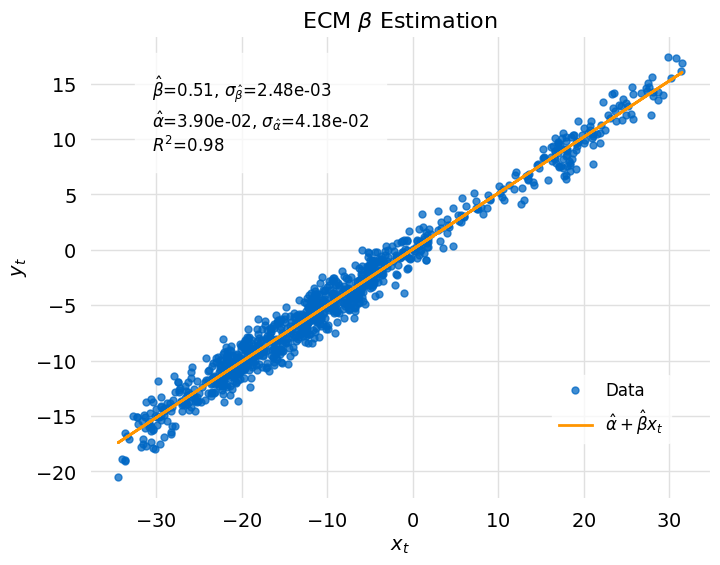

In [93]:
ecm_beta(yt, beta_result_model, xt)

### $\gamma$ and $\lambda$ Estimation

In [94]:
result, gamma_lambda_result_model = ecm.compute_gamma_lambda_estimate(yt, xt, beta_result_model.params[0].est)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.413
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     350.1
Date:                Sun, 01 Oct 2023   Prob (F-statistic):          6.99e-116
Time:                        12:42:27   Log-Likelihood:                -1393.5
No. Observations:                 999   AIC:                             2793.
Df Residuals:                     996   BIC:                             2808.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0196      0.031      0.633      0.527      -0.041       0.080
x1             0.5200      0.027     18.964      0.000       0.466       0.574
x2            -0.5124      0.028    -18.526      0.000      -0.567      -0.458
==============================================================================
Omnibus:                        2.001   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.368   Jarque-Bera (JB):                1.837
Skew:                          -0.001   Prob(JB):                        0.399
Kurtosis:                       2.790   Cond. No.                         1.13
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [95]:
print(gamma_lambda_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.01958301466906107,
      "err": 0.030953496968542264,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "df4cc0c9-4b98-45ba-ae77-4eb220ed6f39",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.5199625907895914,
         "err": 0.027418261617958812,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "df4cc0c9-4b98-45ba-ae77-4eb220ed6f39",
         "param_type": "OLS_PARAM"
      },
      {
         "est": -0.5124108984175029,
         "err": 0.027659024639464503,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "df4cc0c9-4b98-45ba-ae77-4eb220ed6f39",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.4128303498983995,
   "param_transforms": [
      {
      